In [36]:
import os; os.listdir('/kaggle/input/datasets/keithaustine/nairobi-synthetic-provider-dataset')

['service_providers.csv',
 'traffic_patterns.csv',
 'provider_availability.csv',
 'historical_bookings.csv',
 'nairobi_areas.csv',
 'clients.csv',
 'ml_features_reference.csv']

In [37]:
import xgboost

In [38]:
import pandas as pd

dataset_path = "/kaggle/input/datasets/keithaustine/nairobi-synthetic-provider-dataset"

df = pd.read_csv(f"{dataset_path}/historical_bookings.csv")

df.head()

,booking_id,provider_id,client_id,service_type,booked_at,day_of_week,day_type,booking_hour,time_slot,provider_area,...,provider_experience_years,provider_avg_response_min,provider_total_jobs,provider_is_verified,provider_hourly_rate_ksh,provider_area_road_quality,client_area_road_quality,job_completed,client_rating_given,arrival_reliability_score
0,B00001,P0023,C0126,plumber,2025-02-15 08:13,Saturday,weekend,8,morning_rush,Runda,...,7,10,539,True,894,good,good,True,3.8,0.9744
1,B00002,P0121,C0323,plumber,2024-06-14 15:09,Friday,weekday,15,early_afternoon,Eastleigh,...,19,41,437,True,1381,poor,poor,True,5.0,0.7068
2,B00003,P0190,C0340,technician,2024-02-09 16:58,Friday,weekday,16,evening_rush,Ngong,...,15,38,465,True,974,poor,good,True,3.2,0.3562
3,B00004,P0172,C0040,electrician,2024-07-29 16:27,Monday,weekday,16,evening_rush,Westlands,...,14,27,1106,True,839,good,poor,True,4.9,0.4747
4,B00005,P0176,C0325,electrician,2024-02-16 12:40,Friday,weekday,12,midday,Lavington,...,19,13,855,False,1087,good,moderate,True,4.5,0.8971


In [39]:
# Dataset dimensions
print("Shape:", df.shape)

# Data types
print("\nData Types")
print(df.dtypes)

# Target statistics
print("\nArrival Reliability Score Statistics")
print(df["arrival_reliability_score"].describe())

# Missing values
print("\nMissing Values")
print(df.isna().sum())

Shape: (3000, 36)

Data Types
booking_id                     object
provider_id                    object
client_id                      object
service_type                   object
booked_at                      object
day_of_week                    object
day_type                       object
booking_hour                    int64
time_slot                      object
provider_area                  object
client_area                    object
provider_lat                  float64
provider_lng                  float64
client_lat                    float64
client_lng                    float64
distance_km                   float64
primary_corridor               object
congestion_multiplier         float64
congestion_level_0_10           int64
avg_speed_kmh                 float64
estimated_travel_min          float64
actual_travel_min             float64
delay_min                     float64
on_time                          bool
provider_rating               float64
provider_completion_

In [40]:
FEATURES = [
    "distance_km",
    "congestion_multiplier",
    "time_slot",
    "provider_area_road_quality",
    "provider_completion_rate"
]

TARGET = "arrival_reliability_score"

FEATURES

['distance_km',
 'congestion_multiplier',
 'time_slot',
 'provider_area_road_quality',
 'provider_completion_rate']

In [41]:
# Columns that should NEVER be used as predictors
LEAKAGE_COLUMNS = [
    "actual_travel_min",
    "delay_min",
    "on_time",
    "job_completed",
    "client_rating_given"
]

print("Leakage Columns:")
print(LEAKAGE_COLUMNS)

Leakage Columns:
['actual_travel_min', 'delay_min', 'on_time', 'job_completed', 'client_rating_given']


In [42]:
X = df[FEATURES]
y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3000, 5)
Target shape: (3000,)


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

categorical_features = [
    "time_slot",
    "provider_area_road_quality"
]

numeric_features = [
    "distance_km",
    "congestion_multiplier",
    "provider_completion_rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2400, 5)
(600, 5)


In [44]:
#Baseline A - Distance Only
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

baselineA = LinearRegression()

baselineA.fit(
    X_train[["distance_km"]],
    y_train
)

predA = baselineA.predict(
    X_test[["distance_km"]]
)

rmse_A = np.sqrt(mean_squared_error(y_test, predA))
mae_A = mean_absolute_error(y_test, predA)

print("Baseline A - Distance Only")
print("Baseline A RMSE:", rmse_A)
print("Baseline A MAE:", mae_A)

Baseline A - Distance Only
Baseline A RMSE: 0.18722795422943497
Baseline A MAE: 0.1513602184750952


In [45]:
# Baseline B data
X_rating = df[["provider_rating"]]
y_rating = df["arrival_reliability_score"]

X_rating_train, X_rating_test, y_rating_train, y_rating_test = train_test_split(
    X_rating,
    y_rating,
    test_size=0.20,
    random_state=42
)

In [46]:
#Baseline B - Rating Only
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

baselineB = LinearRegression()

baselineB.fit(
    X_rating_train,
    y_rating_train
)

predB = baselineB.predict(X_rating_test)

rmse_B = np.sqrt(
    mean_squared_error(y_rating_test, predB)
)

mae_B = mean_absolute_error(
    y_rating_test,
    predB
)

print("Baseline B - Provider Rating")
print("RMSE:", rmse_B)
print("MAE:", mae_B)

Baseline B - Provider Rating
RMSE: 0.19356760168148968
MAE: 0.15850065439912117


In [47]:
#XGBoost Pipeline
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [48]:
#XGBoost (default parameters)
pred_xgb = xgb_pipeline.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost RMSE: 0.15827654584374082
XGBoost MAE: 0.12474702134394647


In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_child_weight": [1, 3]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['distance_km',
                                                                          'congestion_multiplier',
                                                                          'provider_completion_rate']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['time_slot',
                                                                          'provider_area_road_quality'])])),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_...
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__min_child_weight': [1, 3]},
             scoring='neg_root_mean_squared_error')

In [50]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3}


In [51]:
best_cv_rmse = -grid_search.best_score_

print("Best Cross-Validation RMSE:", best_cv_rmse)

Best Cross-Validation RMSE: 0.14047964037159727


In [52]:
best_model = grid_search.best_estimator_

pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(
    mean_squared_error(y_test, pred_tuned)
)

mae_tuned = mean_absolute_error(
    y_test,
    pred_tuned
)

print("Tuned XGBoost")
print("RMSE:", rmse_tuned)
print("MAE:", mae_tuned)

Tuned XGBoost
RMSE: 0.1416863961995932
MAE: 0.11598403719409307


In [53]:
results = pd.DataFrame({
    "Model": [
        "Baseline A (Distance)",
        "Baseline B (Provider Rating)",
        "XGBoost (Default)",
        "XGBoost (Tuned)"
    ],
    "RMSE": [
        rmse_A,
        rmse_B,
        rmse_xgb,
        rmse_tuned
    ],
    "MAE": [
        mae_A,
        mae_B,
        mae_xgb,
        mae_tuned
    ]
})

results

,Model,RMSE,MAE
0,Baseline A (Distance),0.187228,0.151360
1,Baseline B (Provider Rating),0.193568,0.158501
2,XGBoost (Default),0.158277,0.124747
3,XGBoost (Tuned),0.141686,0.115984


In [54]:
# Cross-validation on the TUNED model (best_model from grid search)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -cv_scores

print("Fold RMSE Scores (Tuned Model)")
print(rmse_scores)

print("\nAverage RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())

Fold RMSE Scores (Tuned Model)
[0.13669737 0.14147709 0.13934093 0.14908472 0.13887686]

Average RMSE: 0.14109539375186922
Standard Deviation: 0.0042735870853422364


In [55]:
import matplotlib.pyplot as plt

# Get feature names after encoding -- from the TUNED best_model
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Feature importance from the TUNED model
importance = best_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                                     Feature  Importance
1                 num__congestion_multiplier    0.515487
2              num__provider_completion_rate    0.165461
0                           num__distance_km    0.097789
8       cat__provider_area_road_quality_good    0.057585
3             cat__time_slot_early_afternoon    0.034531
5                 cat__time_slot_mid_morning    0.031358
4                cat__time_slot_evening_rush    0.030325
9   cat__provider_area_road_quality_moderate    0.026514
10      cat__provider_area_road_quality_poor    0.018350
6                      cat__time_slot_midday    0.015973
7                cat__time_slot_morning_rush    0.006628


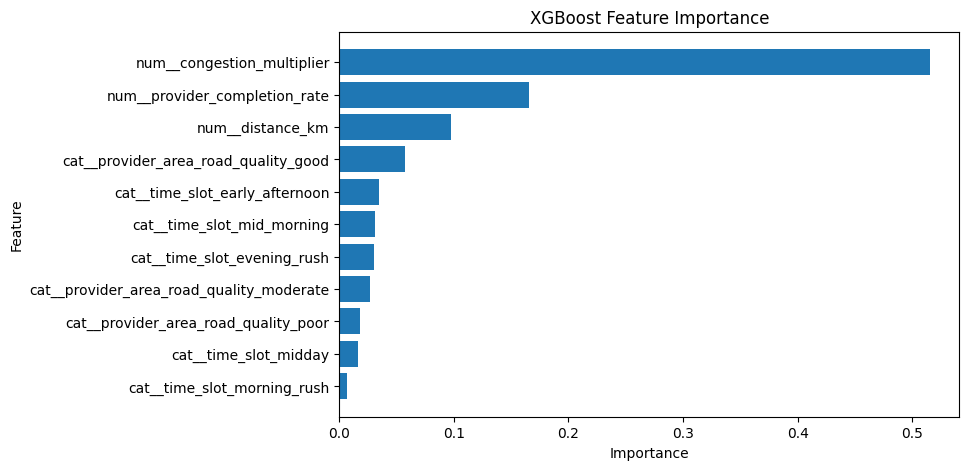

In [56]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [57]:
import joblib

joblib.dump(
    best_model,
    "/kaggle/working/xgboost_arrival_reliability_pipeline.pkl"
)

print("Tuned pipeline saved successfully!")

Tuned pipeline saved successfully!


In [58]:
results.to_csv("/kaggle/working/model_comparison_results.csv", index=False)
importance_df.to_csv("/kaggle/working/feature_importance.csv", index=False)